In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas.testing as tm
%matplotlib inline

In [105]:
url = "/NO2_daily_aqs_data_downloaded_2026-09-17 19_23_13.csv"
df = pd.read_csv(url)
df.head()

,Date,Site ID,POC,Daily Max NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2023-01-01,150030010,1,9.0,Parts per billion,8,Kapolei,24,100,42602,...,17.9,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Hawaii State Department Of Health,POPULATION EXPOSURE,Y,NaN,5,NaN
1,2023-01-02,150030010,1,6.6,Parts per billion,6,Kapolei,20,83,42602,...,17.9,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Hawaii State Department Of Health,POPULATION EXPOSURE,Y,NaN,5,NaN
2,2023-01-03,150030010,1,22.6,Parts per billion,21,Kapolei,24,100,42602,...,17.9,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Hawaii State Department Of Health,POPULATION EXPOSURE,Y,NaN,5,NaN
3,2023-01-04,150030010,1,18.2,Parts per billion,17,Kapolei,24,100,42602,...,17.9,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Hawaii State Department Of Health,POPULATION EXPOSURE,Y,NaN,5,NaN
4,2023-01-05,150030010,1,23.2,Parts per billion,22,Kapolei,24,100,42602,...,17.9,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Hawaii State Department Of Health,POPULATION EXPOSURE,Y,NaN,5,NaN


Información detallada

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          357 non-null    object 
 1   Site ID                       357 non-null    int64  
 2   POC                           357 non-null    int64  
 3   Daily Max NO2 Concentration   357 non-null    float64
 4   Units                         357 non-null    object 
 5   Daily AQI Value               357 non-null    int64  
 6   Local Site Name               357 non-null    object 
 7   Daily Obs Count               357 non-null    int64  
 8   Percent Complete              357 non-null    int64  
 9   AQS Parameter Code            357 non-null    int64  
 10  AQS Parameter Description     357 non-null    object 
 11  Method Code                   357 non-null    int64  
 12  Method Description            357 non-null    object 
 13  CBSA 

Resumen de estadísticas

In [107]:
df.describe().round(3)

,Site ID,POC,Daily Max NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Dominant Source,Elevation (m),Networks,Probe Height (m),QA Primary Monitor?
count,357.0,357.0,357.000,357.000,357.000,357.000,357.0,357.0,357.0,357.000,357.000,0.0,357.0,0.0,357.0,0.0
mean,150030010.0,1.0,9.039,8.199,23.434,97.689,42602.0,212.0,46520.0,21.324,-158.089,NaN,17.9,NaN,5.0,NaN
std,0.0,0.0,5.131,4.721,1.914,7.922,0.0,0.0,0.0,0.000,0.000,NaN,0.0,NaN,0.0,NaN
min,150030010.0,1.0,2.000,2.000,4.000,17.000,42602.0,212.0,46520.0,21.324,-158.089,NaN,17.9,NaN,5.0,NaN
25%,150030010.0,1.0,5.400,5.000,24.000,100.000,42602.0,212.0,46520.0,21.324,-158.089,NaN,17.9,NaN,5.0,NaN
50%,150030010.0,1.0,7.600,7.000,24.000,100.000,42602.0,212.0,46520.0,21.324,-158.089,NaN,17.9,NaN,5.0,NaN
75%,150030010.0,1.0,11.200,10.000,24.000,100.000,42602.0,212.0,46520.0,21.324,-158.089,NaN,17.9,NaN,5.0,NaN
max,150030010.0,1.0,34.300,32.000,24.000,100.000,42602.0,212.0,46520.0,21.324,-158.089,NaN,17.9,NaN,5.0,NaN


In [128]:
l = list(df.columns)
print(l)

['Date', 'Site ID', 'POC', 'Daily Max NO2 Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name', 'Site Latitude', 'Site Longitude', 'Dominant Source', 'Elevation (m)', 'Measurement Scale', 'Measurement Scale Definition', 'Monitor Type', 'Monitoring Agency', 'Monitoring Objective', 'NAAQS Primary Monitor?', 'Networks', 'Probe Height (m)', 'QA Primary Monitor?']


In [129]:
l = ['Daily AQI Value','Daily Obs Count','Percent Complete','Daily Max NO2 Concentration']

Diagramas de caja y bigote

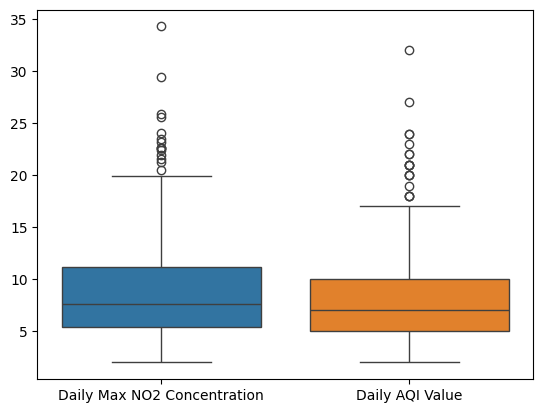

In [130]:
sns.boxplot(data=df[['Daily Max NO2 Concentration', 'Daily AQI Value']])
plt.show()

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [133]:
X = df[['Daily Max NO2 Concentration']]
y = df['Daily AQI Value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [122]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [124]:
y_pred = modelo.predict(X_test)

Gráfico de regresión

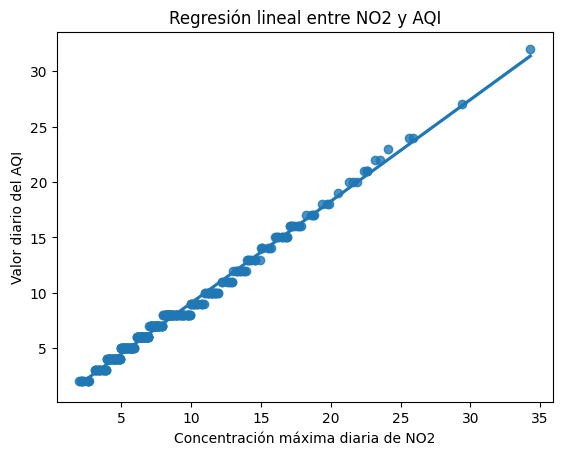

In [127]:
sns.regplot(x='Daily Max NO2 Concentration',y='Daily AQI Value',data=df)
plt.xlabel('Concentración máxima diaria de NO2')
plt.ylabel('Valor diario del AQI')
plt.title('Regresión lineal entre NO2 y AQI')
plt.show()

Evaluación del modelo

In [136]:
from sklearn.metrics import mean_squared_error, r2_score

In [137]:
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.994470471307277
MSE: 0.15049714071186368
